# EEG Multi-Paradigm Dataset Exploration

This notebook explores a diverse set of EEG datasets across **three major Brain-Computer Interface (BCI) paradigms**:

1. [Event-Related Potentials (ERP - P300)](#event-related-potentials-erp---p300)
2. [Motor Imagery (MI)](#motor-imagery-mi)
3. [Steady-State Visual Evoked Potentials (SSVEP)](#steady-state-visual-evoked-potentials-ssvep)

All datasets are sourced from the [MOABB](https://moabb.neurotechx.com/docs/datasets.html) (Mother of All BCI Benchmarks) archive. To ensure consistency, all data are either recorded at or resampled to **128 Hz**, and segmented into **2-second epochs**.

This notebook includes:
- Data loading and shape overview
- Class distribution visualization
- EEG montage visualization (used for cross-dataset analysis)
- Label conversion to numeric format (compatible with PyTorch)


In [1]:
import os
import numpy as np
import pickle
from eeg_positions import get_elec_coords
import pandas as pd
import matplotlib.pyplot as plt
from eeg_positions.config import RADIUS_INNER_CONTOUR
from eeg_positions.utils import _get_coords_on_circle

In [3]:
def _plot_2d_head(radius_inner_contour=None, show_axis=False):
    """Plot a head in 2D.

    Parameters
    ----------
    radius_inner_contour : int | float | None
        If int or float, draw a circle with that radius to visualize an inner
        contour line. Defaults to None, not drawing a circle. Can instead also
        be conveniently set to ``eeg_positions.config.RADIUS_INNER_CONTOUR``,
        which is the Fpz-T8-Oz-T7 contour line.
    show_axis : bool
        Whether or not to show the coordinate system x- and y-axes. Defaults to False.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The Figure object.
    ax : matplotlib.axes.Axes
        The Axes object.

    """
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.axes.set_aspect("equal")
    plt.xlabel("x")
    plt.ylabel("y")

    head_radius = 0.9
    linewidth = 0.5

    # Draw head shape
    head_shape = plt.Circle(
        (0, 0), head_radius, color="k", fill=False, linewidth=linewidth
    )
    ax.add_artist(head_shape)

    if radius_inner_contour is not None:
        head_shape = plt.Circle(
            (0, 0), radius_inner_contour, color="k", fill=False, linewidth=linewidth / 2
        )
        ax.add_artist(head_shape)

    # Draw nose
    nose_width = 5
    nose_base_l = _get_coords_on_circle(r=head_radius, steps=nose_width)[-1]
    nose_base_r = _get_coords_on_circle(r=head_radius, steps=nose_width)[1]
    nose_tip = 0.95
    ax.plot((nose_base_l[0], 0), (nose_base_l[1], nose_tip), "k", linewidth=linewidth)
    ax.plot((nose_base_r[0], 0), (nose_base_r[1], nose_tip), "k", linewidth=linewidth)

    ax.vlines(
        x=0,
        ymin=-1,
        ymax=1,
        color="black",
        linewidth=linewidth / 2,
        linestyles="dotted",
    )
    ax.hlines(
        y=0,
        xmin=-1,
        xmax=1,
        color="black",
        linewidth=linewidth / 2,
        linestyles="dotted",
    )

    # Adjust limits
    ax.set_xlim([-head_radius * 1.1, head_radius * 1.1])
    ax.set_ylim([-head_radius * 1.18, head_radius * 1.1])

    fig.set_layout_engine("constrained")
    if not show_axis:
        ax.set_axis_off()

    return fig, ax

def plot_coords_2(coords, scatter_kwargs={}, text_kwargs={}):
    """Plot standard EEG electrode coordinates.

    Parameters
    ----------
    coords : pandas.DataFrame
        The standard EEG electrode coordinates as computed on a sphere.
        A pandas DataFrame object with the columns ``"label"``, ``"x"``,
        ``"y"``, and optionally ``"z"``.
    scatter_kwargs : dict
        Optional keyword arguments to be passed to the
        :meth:`matplotlib.axes.Axes.scatter`
        or its 3D variant, depending on the dimensions of `coords`.
    text_kwargs : dict
        Optional keyword arguments to be passed to the
        :meth:`matplotlib.axes.Axes.text`.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The Figure object.
    ax : matplotlib.axes.Axes
        The Axes object.

    """
    # input check
    if not isinstance(coords, pd.DataFrame):
        raise ValueError("`coords` must be a pandas DataFrame object.")
    else:
        for colname in ["label", "x", "y"]:
            if colname not in coords.columns:
                raise ValueError(f"`coords` does not have a required column {colname}.")
    # update kwargs
    scatter_settings = dict()
    scatter_settings.update(scatter_kwargs)
    text_settings = dict(fontsize=6)
    text_settings.update(text_kwargs)

    fig, ax = _plot_2d_head(RADIUS_INNER_CONTOUR)
    ax.scatter(coords["x"], coords["y"], zorder=2.5, **scatter_settings)
    for _, row in coords.iterrows():
        ax.text(row["x"], row["y"], row["label"], **text_settings)
    return fig, ax

# %% cell: Plot label distribution
def plot_label_distribution(labels, set_name, ax=None):
    unique, counts = np.unique(labels, return_counts=True)
    if ax is None:
        ax = plt.gca()
    ax.bar(unique, counts, label=set_name, alpha=0.7)
    ax.set_xticks(unique)
    ax.set_xlabel('Class label')
    ax.set_ylabel('Count')
    ax.set_title(f'{set_name} set label distribution')
    for i, c in zip(unique, counts):
        ax.text(i, c, str(c), ha='center', va='bottom', fontsize=8)

## 📁 Event-Related Potentials (ERP - P300)

**P300** is a positive deflection in EEG voltage that occurs approximately 300 ms after detecting a relevant or rare stimulus. Datasets in this category are typically used in **oddball** or **speller paradigms** where users focus on rare targets among frequent non-targets.


Number of samples:
  Train: (32985, 16, 128)
  Val:   (11928, 16, 128)
  Test:  (16102, 16, 128)

Train set label statistics:
  Class NonTarget: 27487 samples
  Class Target: 5498 samples

Val set label statistics:
  Class NonTarget: 9940 samples
  Class Target: 1988 samples

Test set label statistics:
  Class NonTarget: 13418 samples
  Class Target: 2684 samples


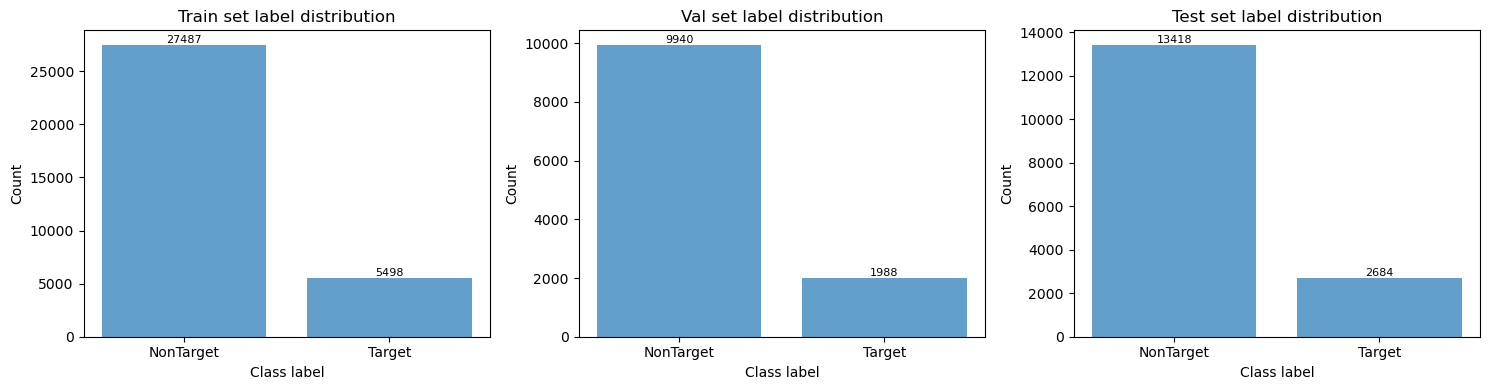

In [6]:
# Load data
Data_npy = np.load('/data/MOABB/Processed/BI2014a/BI2014a.npy', allow_pickle=True)
Data = {}
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']

# %% cell: Print number of samples in each set
print("Number of samples:")
print(f"  Train: {Data['train_data'].shape}")
print(f"  Val:   {Data['val_data'].shape}")
print(f"  Test:  {Data['test_data'].shape}")

# Print statistics
for split in ['train', 'val', 'test']:
    labels = Data[f'{split}_label']
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{split.capitalize()} set label statistics:")
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c} samples")

# Plot distributions
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i, split in enumerate(['train', 'val', 'test']):
    plot_label_distribution(Data[f'{split}_label'], split.capitalize(), ax=axs[i])
plt.tight_layout()
plt.show()

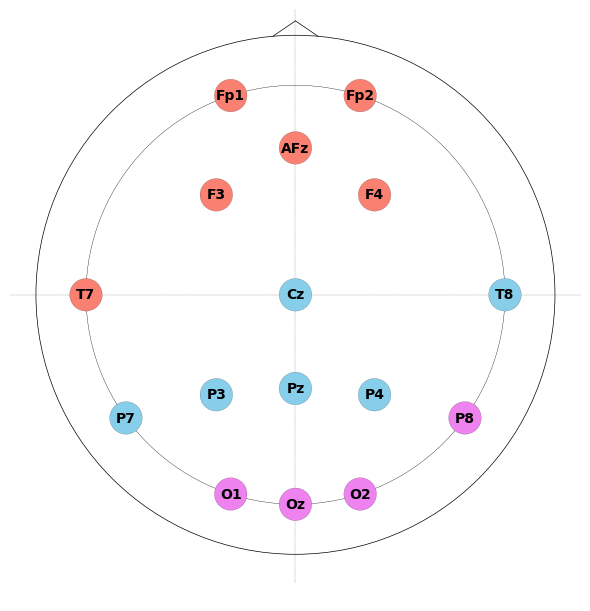

In [8]:
chans = ['Fp1','Fp2','F3','AFz','F4','T7','Cz','T8','P7','P3','Pz','P4','P8','O1','Oz','O2']
coords = get_elec_coords(elec_names=chans)
colors = (
    ["salmon"] * 6
    + ["skyblue"] * 6
    + ["violet"] * 4
)

fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 550,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 10,  # smaller font siz
        "fontweight": "bold",  # make font bold
    },
)

In [12]:
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']

# Convert string labels to numeric: "NonTarget" → 0, "Target" → 1
label_map = {'NonTarget': 0, 'Target': 1}
Data['train_label'] = np.vectorize(label_map.get)(Data['train_label'])
Data['val_label'] = np.vectorize(label_map.get)(Data['val_label'])
Data['test_label'] = np.vectorize(label_map.get)(Data['test_label'])

# Save processed data
data_dict = {
    'X_train': Data['train_data'], 'Y_train': Data['train_label'],
    'X_val': Data['val_data'], 'Y_val': Data['val_label'],
    'X_test': Data['test_data'], 'Y_test': Data['test_label']
}
os.makedirs('/data/EEG-X/Processed/BI2014a', exist_ok=True)
save_path = '/data/EEG-X/Processed/BI2014a/BI2014a.npy'
with open(save_path, 'wb') as f:
    pickle.dump(data_dict, f)

print("✅ Labels converted and data saved successfully.")

✅ Labels converted and data saved successfully.


-----------------------
### • EPFLP300

Recorded during a **visual P300 speller experiment** at EPFL. The dataset features clean and well-labeled signals with varied stimulus conditions, suitable for ERP classification tasks.

Number of samples:
  Train: (13166, 32, 128)
  Val:   (3256, 32, 128)
  Test:  (9894, 32, 128)

Train set label statistics:
  Class NonTarget: 10973 samples
  Class Target: 2193 samples

Val set label statistics:
  Class NonTarget: 2712 samples
  Class Target: 544 samples

Test set label statistics:
  Class NonTarget: 8240 samples
  Class Target: 1654 samples


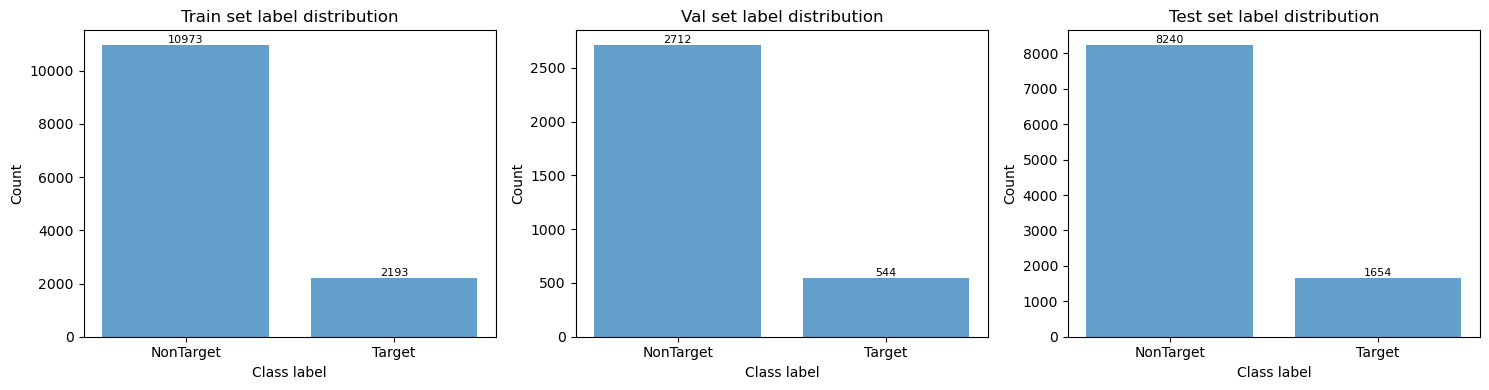

In [17]:
Data_npy = np.load('/data/MOABB/Processed/EPFLP300/EPFLP300.npy', allow_pickle=True)
Data = {}
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']

# %% cell: Print number of samples in each set
print("Number of samples:")
print(f"  Train: {Data['train_data'].shape}")
print(f"  Val:   {Data['val_data'].shape}")
print(f"  Test:  {Data['test_data'].shape}")

# Print statistics
for split in ['train', 'val', 'test']:
    labels = Data[f'{split}_label']
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{split.capitalize()} set label statistics:")
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c} samples")

# Plot distributions
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i, split in enumerate(['train', 'val', 'test']):
    plot_label_distribution(Data[f'{split}_label'], split.capitalize(), ax=axs[i])
plt.tight_layout()
plt.show()

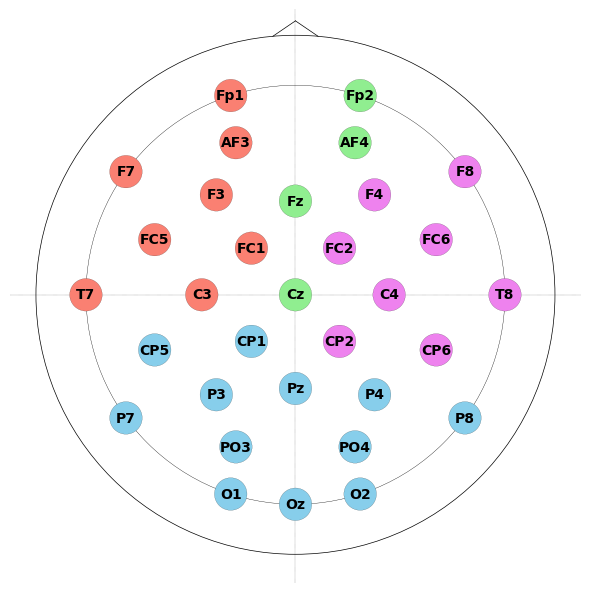

In [18]:
chans = ['Fp1','AF3','F7','F3','FC1','FC5','T7','C3','CP1','CP5','P7','P3','Pz','PO3','O1','Oz','O2','PO4','P4','P8','CP6','CP2','C4','T8','FC6','FC2','F4','F8','AF4','Fp2','Fz','Cz']  
coords = get_elec_coords(elec_names=chans)
colors = (
    ["salmon"] * 8
    + ["skyblue"] * 12
    + ["violet"] * 8
    + ["lightgreen"] * 4
)


fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 550,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 10,  # smaller font siz
        "fontweight": "bold",  # make font bold
    },
)

In [19]:
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']

# Convert string labels to numeric: "NonTarget" → 0, "Target" → 1
label_map = {'NonTarget': 0, 'Target': 1}
Data['train_label'] = np.vectorize(label_map.get)(Data['train_label'])
Data['val_label'] = np.vectorize(label_map.get)(Data['val_label'])
Data['test_label'] = np.vectorize(label_map.get)(Data['test_label'])

# Save processed data
data_dict = {
    'X_train': Data['train_data'], 'Y_train': Data['train_label'],
    'X_val': Data['val_data'], 'Y_val': Data['val_label'],
    'X_test': Data['test_data'], 'Y_test': Data['test_label']
}
os.makedirs('/data/EEG-X/Processed/EPFLP300', exist_ok=True)
save_path = '/data/EEG-X/Processed/EPFLP300/EPFLP300.npy'
with open(save_path, 'wb') as f:
    pickle.dump(data_dict, f)

print("✅ Labels converted and data saved successfully.")

✅ Labels converted and data saved successfully.


-------------------
## Motor Imagery (MI)

**Motor Imagery** involves mental simulation of body movements (e.g., left/right hand), which alters EEG signals, especially in the **mu (8–13 Hz)** and **beta (13–30 Hz)** bands. This category is widely used for building control systems through imagined movement.



### Physionet MI

The PhysionetMI dataset contains EEG recordings collected during motor imagery tasks. Data were recorded using a 64-channel 10-10 electrode system. The dataset consists of over 1,500 one- and two-minute EEG recordings, obtained from 109 volunteers.




Number of samples:
  Train: (11310, 64, 256)
  Val:   (3654, 64, 256)
  Test:  (4058, 64, 256)

Train set label statistics:
  Class feet: 1456 samples
  Class hands: 1469 samples
  Class left_hand: 1481 samples
  Class rest: 5460 samples
  Class right_hand: 1444 samples

Val set label statistics:
  Class feet: 475 samples
  Class hands: 470 samples
  Class left_hand: 472 samples
  Class rest: 1764 samples
  Class right_hand: 473 samples

Test set label statistics:
  Class feet: 524 samples
  Class hands: 526 samples
  Class left_hand: 527 samples
  Class rest: 1960 samples
  Class right_hand: 521 samples


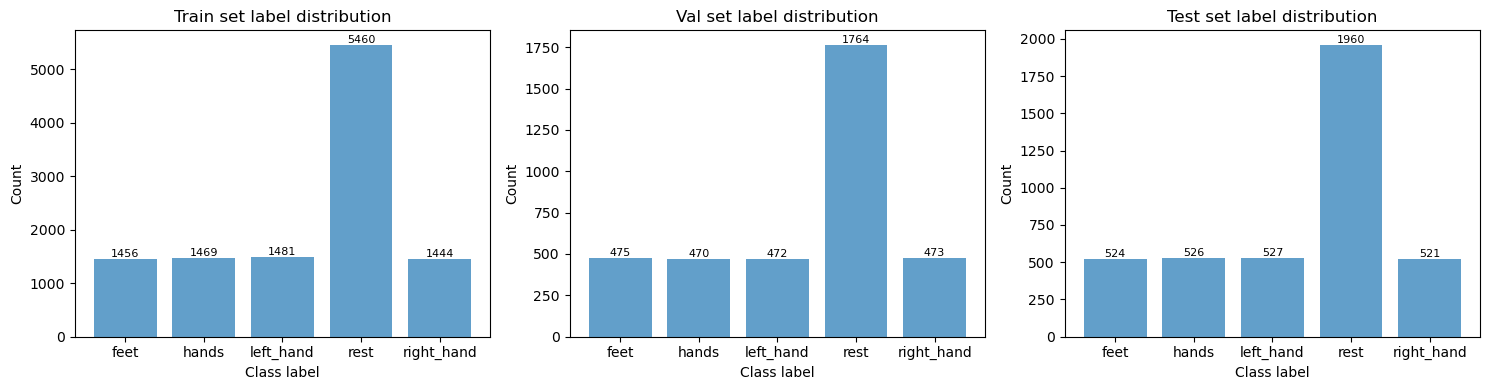

In [33]:
# Load data
Data_npy = np.load('/data/MOABB/Processed/PhysionetMI/PhysionetMI.npy', allow_pickle=True)
Data = {}
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']

# %% cell: Print number of samples in each set
print("Number of samples:")
print(f"  Train: {Data['train_data'].shape}")
print(f"  Val:   {Data['val_data'].shape}")
print(f"  Test:  {Data['test_data'].shape}")
# Print statistics
for split in ['train', 'val', 'test']:
    labels = Data[f'{split}_label']
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{split.capitalize()} set label statistics:")
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c} samples")

# Plot distributions
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i, split in enumerate(['train', 'val', 'test']):
    plot_label_distribution(Data[f'{split}_label'], split.capitalize(), ax=axs[i])
plt.tight_layout()
plt.show()

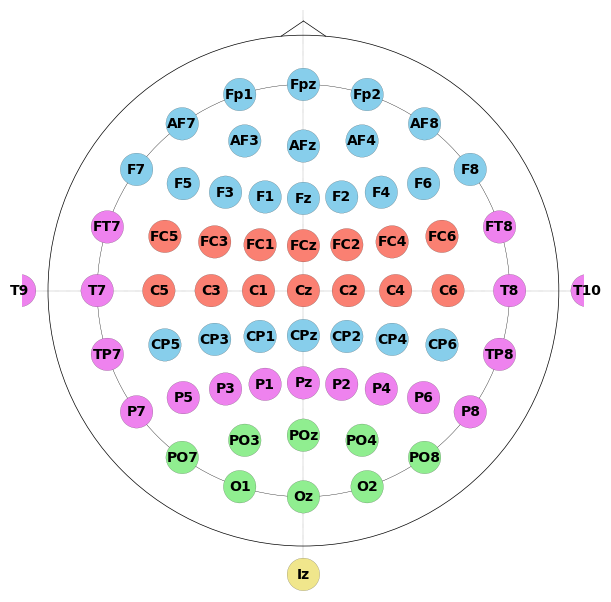

In [34]:
chans = ['FC5','FC3','FC1','FCz','FC2','FC4','FC6','C5','C3','C1','Cz','C2','C4','C6','CP5','CP3','CP1',
'CPz','CP2','CP4','CP6','Fp1','Fpz','Fp2','AF7','AF3','AFz','AF4','AF8','F7','F5','F3','F1','Fz',
'F2','F4','F6','F8','FT7','FT8','T7','T8','T9','T10','TP7','TP8','P7','P5','P3','P1','Pz','P2',
'P4','P6','P8','PO7','PO3','POz','PO4','PO8','O1','Oz','O2','Iz']

coords = get_elec_coords(elec_names=chans)
colors = (
    ["salmon"] * 14
    + ["skyblue"] * 24
    + ["violet"] * 17
    + ["lightgreen"] * 8
    + ["khaki"] * 1
)


fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 550,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 10,  # smaller font siz
        "fontweight": "bold",  # make font bold
    },
)

In [35]:
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']

# Convert string labels to numeric 
label_map = {'feet': 0, 'left_hand': 1, 'right_hand': 2, 'hands': 3, 'rest': 4}
Data['train_label'] = np.vectorize(label_map.get)(Data['train_label'])
Data['val_label'] = np.vectorize(label_map.get)(Data['val_label'])
Data['test_label'] = np.vectorize(label_map.get)(Data['test_label'])

# Save processed data
data_dict = {
    'X_train': Data['train_data'], 'Y_train': Data['train_label'],
    'X_val': Data['val_data'], 'Y_val': Data['val_label'],
    'X_test': Data['test_data'], 'Y_test': Data['test_label']
}
os.makedirs('/data/EEG-X/Processed/PhysionetMI', exist_ok=True)
save_path = '/data/EEG-X/Processed/PhysionetMI/PhysionetMI.npy'
with open(save_path, 'wb') as f:
    pickle.dump(data_dict, f)

print("✅ Labels converted and data saved successfully.")

✅ Labels converted and data saved successfully.


### • BNCI2014

Part of the BNCI Horizon 2020 dataset series. Provides **multi-subject and multi-session** MI recordings, enabling robust testing for subject adaptation and session generalization.

Number of samples:
  Train: (2880, 22, 256)
  Val:   (576, 22, 256)
  Test:  (1728, 22, 256)

Train set label statistics:
  Class feet: 720 samples
  Class left_hand: 720 samples
  Class right_hand: 720 samples
  Class tongue: 720 samples

Val set label statistics:
  Class feet: 144 samples
  Class left_hand: 144 samples
  Class right_hand: 144 samples
  Class tongue: 144 samples

Test set label statistics:
  Class feet: 432 samples
  Class left_hand: 432 samples
  Class right_hand: 432 samples
  Class tongue: 432 samples


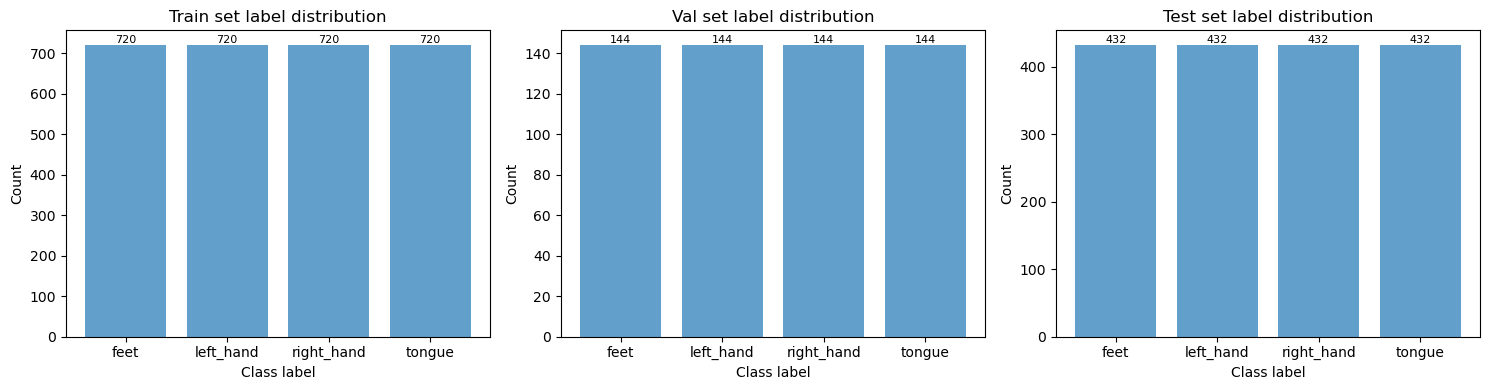

In [38]:
# Load data
Data_npy = np.load('/data/MOABB/Processed/BNCI2014_001/BNCI2014_001.npy', allow_pickle=True)
Data = {}
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']

# %% cell: Print number of samples in each set
print("Number of samples:")
print(f"  Train: {Data['train_data'].shape}")
print(f"  Val:   {Data['val_data'].shape}")
print(f"  Test:  {Data['test_data'].shape}")
# Print statistics
for split in ['train', 'val', 'test']:
    labels = Data[f'{split}_label']
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{split.capitalize()} set label statistics:")
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c} samples")

# Plot distributions
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i, split in enumerate(['train', 'val', 'test']):
    plot_label_distribution(Data[f'{split}_label'], split.capitalize(), ax=axs[i])
plt.tight_layout()
plt.show()

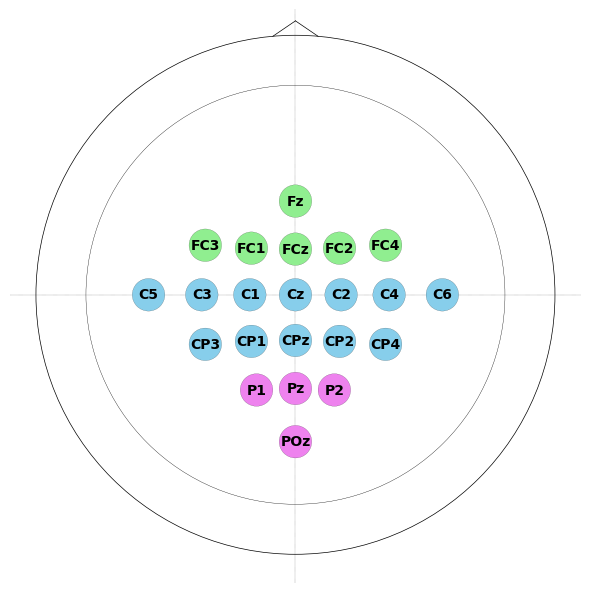

In [39]:
chans = ['Fz','FC3','FC1','FCz','FC2','FC4','C5','C3','C1','Cz','C2','C4','C6','CP3','CP1','CPz','CP2','CP4','P1','Pz','P2','POz']
coords = get_elec_coords(elec_names=chans)
colors = (
    ["lightgreen"] * 6
    + ["skyblue"] * 12
    + ["violet"] * 4
)

fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 550,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 10,  # smaller font siz
        "fontweight": "bold",  # make font bold
    },
)

In [40]:
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']

# Convert string labels to numeric rest:0, right_hand:1, left_hand:2, tongue:3
label_map = {'feet': 0, 'left_hand': 1, 'right_hand': 2, 'tongue': 3}
Data['train_label'] = np.vectorize(label_map.get)(Data['train_label'])
Data['val_label'] = np.vectorize(label_map.get)(Data['val_label'])
Data['test_label'] = np.vectorize(label_map.get)(Data['test_label'])

# Save processed data
data_dict = {
    'X_train': Data['train_data'], 'Y_train': Data['train_label'],
    'X_val': Data['val_data'], 'Y_val': Data['val_label'],
    'X_test': Data['test_data'], 'Y_test': Data['test_label']
}
os.makedirs('/data/EEG-X/Processed/BNCI2014_001', exist_ok=True)
save_path = '/data/EEG-X/Processed/BNCI2014_001/BNCI2014_001.npy'
with open(save_path, 'wb') as f:
    pickle.dump(data_dict, f)

print("✅ Labels converted and data saved successfully.")

✅ Labels converted and data saved successfully.


--------------------------
## 🔁 Steady-State Visual Evoked Potentials (SSVEP)

**SSVEP** responses are elicited when a person focuses on a flickering visual stimulus. The brain's response matches the flicker frequency, enabling reliable frequency-based classification — a key mechanism in high-speed BCI systems.


### • Wang2016

Features SSVEP responses to **multiple flickering frequencies**. Useful for studying frequency recognition and cross-subject generalization in SSVEP decoding.


Number of samples:
  Train: (4800, 62, 256)
  Val:   (1440, 62, 256)
  Test:  (1920, 62, 256)

Train set label statistics:
  Class 10: 120 samples
  Class 10.2: 120 samples
  Class 10.4: 120 samples
  Class 10.6: 120 samples
  Class 10.8: 120 samples
  Class 11: 120 samples
  Class 11.2: 120 samples
  Class 11.4: 120 samples
  Class 11.6: 120 samples
  Class 11.8: 120 samples
  Class 12: 120 samples
  Class 12.2: 120 samples
  Class 12.4: 120 samples
  Class 12.6: 120 samples
  Class 12.8: 120 samples
  Class 13: 120 samples
  Class 13.2: 120 samples
  Class 13.4: 120 samples
  Class 13.6: 120 samples
  Class 13.8: 120 samples
  Class 14: 120 samples
  Class 14.2: 120 samples
  Class 14.4: 120 samples
  Class 14.6: 120 samples
  Class 14.8: 120 samples
  Class 15: 120 samples
  Class 15.2: 120 samples
  Class 15.4: 120 samples
  Class 15.6: 120 samples
  Class 15.8: 120 samples
  Class 8: 120 samples
  Class 8.2: 120 samples
  Class 8.4: 120 samples
  Class 8.6: 120 samples
  Class 8.8

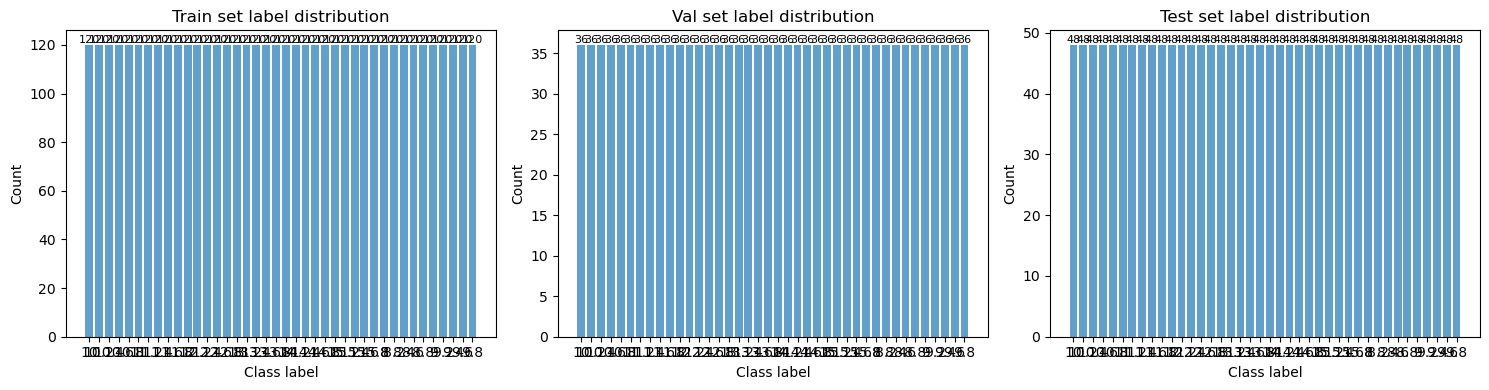

In [4]:
# Load data
Data_npy = np.load('/data/MOABB/Processed/Wang2016/Wang2016.npy', allow_pickle=True)
Data = {}
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']

# %% cell: Print number of samples in each set
print("Number of samples:")
print(f"  Train: {Data['train_data'].shape}")
print(f"  Val:   {Data['val_data'].shape}")
print(f"  Test:  {Data['test_data'].shape}")
# Print statistics
for split in ['train', 'val', 'test']:
    labels = Data[f'{split}_label']
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{split.capitalize()} set label statistics:")
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c} samples")

# Plot distributions
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i, split in enumerate(['train', 'val', 'test']):
    plot_label_distribution(Data[f'{split}_label'], split.capitalize(), ax=axs[i])
plt.tight_layout()
plt.show()

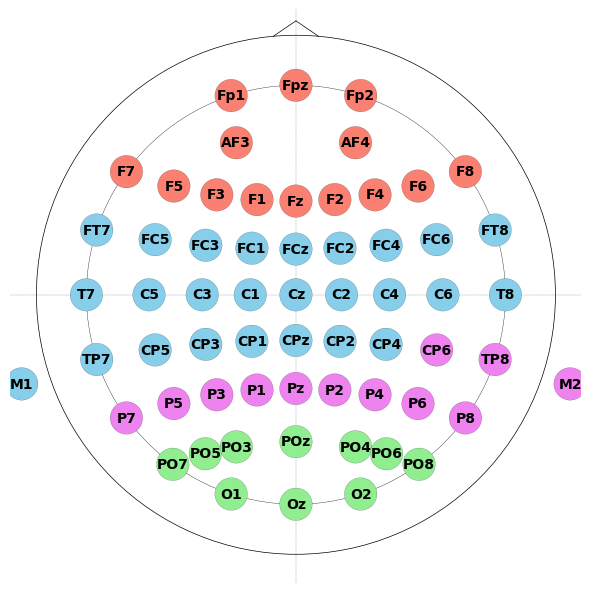

In [12]:
chans = ['Fp1','Fpz','Fp2','AF3','AF4','F7','F5','F3','F1','Fz','F2','F4','F6','F8','FT7','FC5',
        'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4',
         'C6', 'T8', 'M1', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'M2', 'P7',
          'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POz', 'PO4', 'PO6', 'PO8',
           'O1', 'Oz', 'O2']


coords = get_elec_coords(elec_names=chans)
colors = (
    ["salmon"] * 14
    + ["skyblue"] * 26
    + ["violet"] * 12
    + ["lightgreen"] * 10
)
fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 550,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 10,  # smaller font siz
        "fontweight": "bold",  # make font bold
    },
)


In [22]:
# Find indices of 'M1' and 'M2' for dropping the channels as M1 and M2 are reference channels
drop_chans = ['M1','M2']
drop_indices = [chans.index(ch) for ch in drop_chans] 
drop_indices

[32, 42]

In [23]:
Data['train_data'] =  np.delete(Data_npy['X_train'], drop_indices, axis=1)
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = np.delete(Data_npy['X_val'], drop_indices, axis=1)
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = np.delete(Data_npy['X_test'], drop_indices, axis=1)
Data['test_label'] = Data_npy['Y_test']



# to do : remove the row of m1 and m2 channels

# Get all unique labels across train/val/test
all_labels = np.unique(np.concatenate([
    Data['train_label'], 
    Data['val_label'], 
    Data['test_label']
]))

# Create a label mapping dictionary
label_map = {label: idx for idx, label in enumerate(sorted(all_labels))}

# Step 3: Apply the mapping to each dataset split
Data['train_label'] = np.vectorize(label_map.get)(Data['train_label'])
Data['val_label'] = np.vectorize(label_map.get)(Data['val_label'])
Data['test_label'] = np.vectorize(label_map.get)(Data['test_label'])

# Save processed data
data_dict = {
    'X_train': Data['train_data'], 'Y_train': Data['train_label'],
    'X_val': Data['val_data'], 'Y_val': Data['val_label'],
    'X_test': Data['test_data'], 'Y_test': Data['test_label']
}
os.makedirs('/data/EEG-X/Processed/Wang2016', exist_ok=True)
save_path = '/data/EEG-X/Processed/Wang2016/Wang2016.npy'
with open(save_path, 'wb') as f:
    pickle.dump(data_dict, f)

print("✅ Labels converted and data saved successfully.")

✅ Labels converted and data saved successfully.


### • Lee2019_SSVEP

A high-quality dataset with **multiple SSVEP visual targets** and detailed labeling. Offers a strong benchmark for multi-class frequency recognition.


Number of samples:
  Train: (6400, 62, 256)
  Val:   (2000, 62, 256)
  Test:  (2400, 62, 256)

Train set label statistics:
  Class 12.0: 1600 samples
  Class 5.45: 1600 samples
  Class 6.67: 1600 samples
  Class 8.57: 1600 samples

Val set label statistics:
  Class 12.0: 500 samples
  Class 5.45: 500 samples
  Class 6.67: 500 samples
  Class 8.57: 500 samples

Test set label statistics:
  Class 12.0: 600 samples
  Class 5.45: 600 samples
  Class 6.67: 600 samples
  Class 8.57: 600 samples


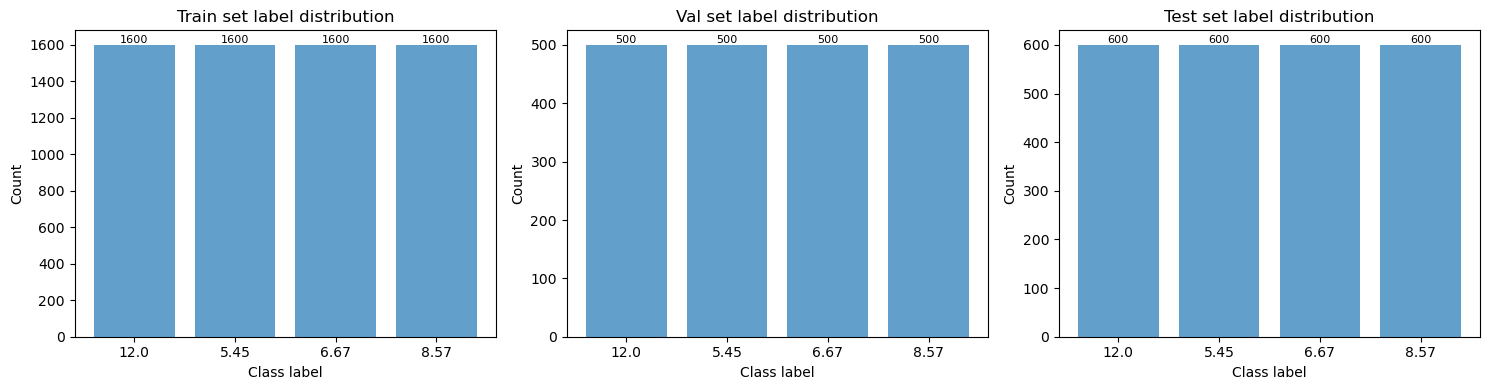

In [24]:
# Load data
Data_npy = np.load('/data/MOABB/Processed/Lee2019_SSVEP/Lee2019_SSVEP.npy', allow_pickle=True)
Data = {}
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']

# %% cell: Print number of samples in each set
print("Number of samples:")
print(f"  Train: {Data['train_data'].shape}")
print(f"  Val:   {Data['val_data'].shape}")
print(f"  Test:  {Data['test_data'].shape}")
# Print statistics
for split in ['train', 'val', 'test']:
    labels = Data[f'{split}_label']
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{split.capitalize()} set label statistics:")
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c} samples")

# Plot distributions
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i, split in enumerate(['train', 'val', 'test']):
    plot_label_distribution(Data[f'{split}_label'], split.capitalize(), ax=axs[i])
plt.tight_layout()
plt.show()

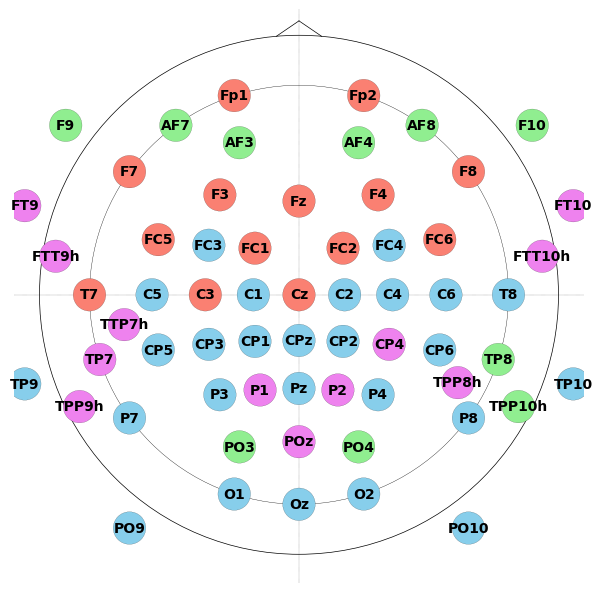

In [25]:
chans = ['Fp1', 'Fp2', 'F7','F3','Fz','F4','F8','FC5','FC1','FC2','FC6','T7','C3','Cz','C4','T8','TP9','CP5','CP1','CP2','CP6','TP10',
'P7','P3','Pz','P4','P8','PO9','O1','Oz','O2','PO10','FC3','FC4','C5','C1','C2','C6','CP3','CPz','CP4','P1','P2','POz','FT9',
'FTT9h','TTP7h','TP7','TPP9h','FT10','FTT10h','TPP8h','TP8','TPP10h','F9','F10','AF7','AF3','AF4','AF8','PO3','PO4']


coords = get_elec_coords(elec_names=chans)
colors = (
    ["salmon"] * 14
    + ["skyblue"] * 26
    + ["violet"] * 12
    + ["lightgreen"] * 10
)
fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 550,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 10,  # smaller font siz
        "fontweight": "bold",  # make font bold
    },
)

In [ ]:
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']


# Get all unique labels across train/val/test
all_labels = np.unique(np.concatenate([
    Data['train_label'], 
    Data['val_label'], 
    Data['test_label']
]))

# Create a label mapping dictionary
label_map = {label: idx for idx, label in enumerate(sorted(all_labels))}

# Step 3: Apply the mapping to each dataset split
Data['train_label'] = np.vectorize(label_map.get)(Data['train_label'])
Data['val_label'] = np.vectorize(label_map.get)(Data['val_label'])
Data['test_label'] = np.vectorize(label_map.get)(Data['test_label'])

# Save processed data
data_dict = {
    'X_train': Data['train_data'], 'Y_train': Data['train_label'],
    'X_val': Data['val_data'], 'Y_val': Data['val_label'],
    'X_test': Data['test_data'], 'Y_test': Data['test_label']
}
os.makedirs('/data/EEG-X/Processed/Lee2019_SSVEP', exist_ok=True)
save_path = '/data/EEG-X/Processed/Lee2019_SSVEP/Lee2019_SSVEP.npy'
with open(save_path, 'wb') as f:
    pickle.dump(data_dict, f)

print("✅ Labels converted and data saved successfully.")

✅ Labels converted and data saved successfully.


### • Kalunga2016

SSVEP signals recorded from a **BCI speller system** in real-world conditions. This dataset includes challenging noise and variability, making it valuable for testing model robustness.

Number of samples:
  Train: (480, 8, 256)
  Val:   (128, 8, 256)
  Test:  (352, 8, 256)

Train set label statistics:
  Class 13: 120 samples
  Class 17: 120 samples
  Class 21: 120 samples
  Class rest: 120 samples

Val set label statistics:
  Class 13: 32 samples
  Class 17: 32 samples
  Class 21: 32 samples
  Class rest: 32 samples

Test set label statistics:
  Class 13: 88 samples
  Class 17: 88 samples
  Class 21: 88 samples
  Class rest: 88 samples


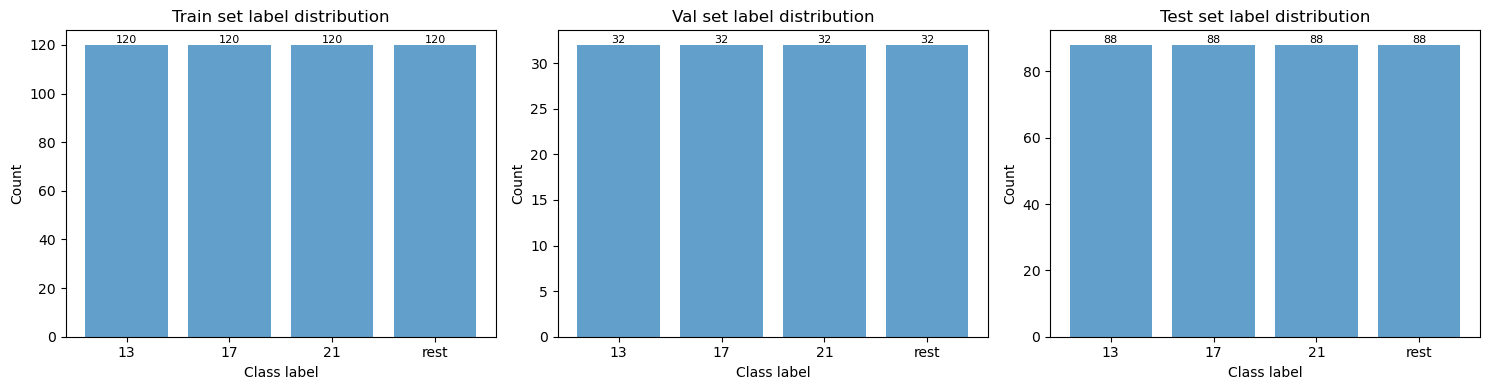

In [27]:
# Load data
Data_npy = np.load('/data/MOABB/Processed/Kalunga2016/Kalunga2016.npy', allow_pickle=True)
Data = {}
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']

# %% cell: Print number of samples in each set
print("Number of samples:")
print(f"  Train: {Data['train_data'].shape}")
print(f"  Val:   {Data['val_data'].shape}")
print(f"  Test:  {Data['test_data'].shape}")
# Print statistics
for split in ['train', 'val', 'test']:
    labels = Data[f'{split}_label']
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{split.capitalize()} set label statistics:")
    for u, c in zip(unique, counts):
        print(f"  Class {u}: {c} samples")

# Plot distributions
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i, split in enumerate(['train', 'val', 'test']):
    plot_label_distribution(Data[f'{split}_label'], split.capitalize(), ax=axs[i])
plt.tight_layout()
plt.show()

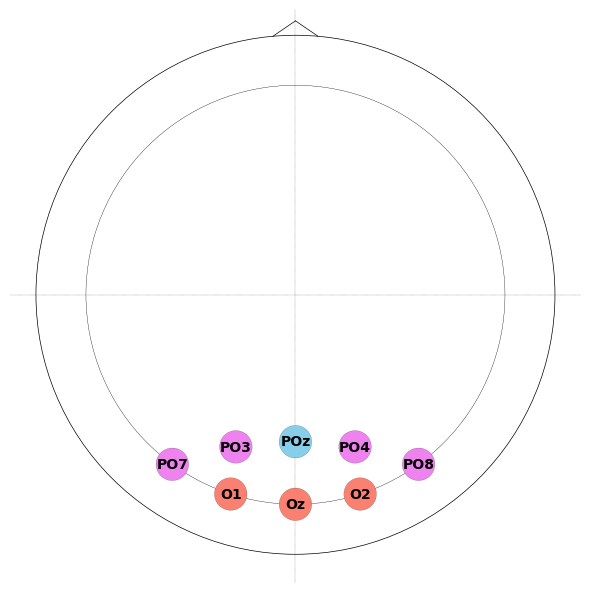

In [28]:
chans = ['Oz','O1','O2','POz','PO3','PO4','PO7','PO8']

coords = get_elec_coords(elec_names=chans)
colors = (
    ["salmon"] * 3
    + ["skyblue"] * 1
    + ["violet"] * 4
)
fig, ax = plot_coords_2(
    coords,
    scatter_kwargs={
        "s": 550,  # electrode size
        "color": colors,
        "edgecolors": "black",  # black electrode outline
        "linewidths": 0.1,  # thin outline
    },
    text_kwargs={
        "ha": "center",  # center electrode label horizontally
        "va": "center",  # center electrode label vertically
        "fontsize": 10,  # smaller font siz
        "fontweight": "bold",  # make font bold
    },
)

In [29]:
Data['train_data'] = Data_npy['X_train']
Data['train_label'] = Data_npy['Y_train']
Data['val_data'] = Data_npy['X_val']
Data['val_label'] = Data_npy['Y_val']
Data['test_data'] = Data_npy['X_test']
Data['test_label'] = Data_npy['Y_test']


# Get all unique labels across train/val/test
all_labels = np.unique(np.concatenate([
    Data['train_label'], 
    Data['val_label'], 
    Data['test_label']
]))

# Create a label mapping dictionary
label_map = {label: idx for idx, label in enumerate(sorted(all_labels))}

# Step 3: Apply the mapping to each dataset split
Data['train_label'] = np.vectorize(label_map.get)(Data['train_label'])
Data['val_label'] = np.vectorize(label_map.get)(Data['val_label'])
Data['test_label'] = np.vectorize(label_map.get)(Data['test_label'])

# Save processed data
data_dict = {
    'X_train': Data['train_data'], 'Y_train': Data['train_label'],
    'X_val': Data['val_data'], 'Y_val': Data['val_label'],
    'X_test': Data['test_data'], 'Y_test': Data['test_label']
}
os.makedirs('/data/EEG-X/Processed/Kalunga2016', exist_ok=True)
save_path = '/data/EEG-X/Processed/Kalunga2016/Kalunga2016.npy'
with open(save_path, 'wb') as f:
    pickle.dump(data_dict, f)

print("✅ Labels converted and data saved successfully.")

✅ Labels converted and data saved successfully.
